# Tutorial - Introduction to Pytorch and Word-level RNN Language Models
This tutorial is adapted from [_Introduction to Pytorch_](https://pytorch.org/tutorials/beginner/introyt.html) tutorial from Pytorch documentations.

In this tutorial, You will learn the basics of Pytorch and how to build and train neural network with Pytorch (Word-level RNN Language models example).

## Part 1: Introduction to Pytorch

PyTorch is an open source machine learning framework based on the Torch library, used for applications such as computer vision and natural language processing, primarily developed by Facebook's AI Research lab.

In [1]:
!nvidia-smi

Wed Mar  4 21:50:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.57                 Driver Version: 581.57         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4080 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   61C    P5             19W /   84W |    1320MiB /  12282MiB |     27%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
#PyTorch include the downloadable datasets (e.g., "torchtext")
# Install the fowlling.
!pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu130

Looking in indexes: https://download.pytorch.org/whl/cu130


Let's start with importing Pytorch

In [3]:
import sys
import torch

print("Python path:", sys.executable)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Torch CUDA version:", torch.version.cuda)
print("GPU Model:",torch.cuda.get_device_name(0))

Python path: c:\Repository\CompScience\CompScienceEnv\Scripts\python.exe
Torch version: 2.10.0+cu130
CUDA available: True
Torch CUDA version: 13.0
GPU Model: NVIDIA GeForce RTX 4080 Laptop GPU


### Tensors
Tensors are a specialized data structure that are very similar to arrays and matrices. In PyTorch, we use tensors to encode the inputs and outputs of a model, as well as the model’s parameters.

Tensors are similar to NumPy’s ndarrays, except that tensors can run on GPUs or other hardware accelerators. In fact, tensors and NumPy arrays can often share the same underlying memory, eliminating the need to copy data (see Bridge with NumPy). Tensors are also optimized for automatic differentiation (we’ll see more about that later in the Autograd section). If you’re familiar with ndarrays, you’ll be right at home with the Tensor API. If not, follow along!

In [4]:
import torch
import numpy as np

Tensors can be created directly from data or from NumPy arrays.

In [5]:
# Directly from data
data = [[1, 2],[3, 4]]
x_data = torch.tensor(data)

# From a NumPy array
np_array = np.array(data)
x_np = torch.from_numpy(np_array)

Tensor attributes describe their shape, datatype, and the device on which they are stored.

In [6]:
print(f"Shape of tensor: {x_data.shape}")
print(f"Datatype of tensor: {x_data.dtype}")
print(f"Device tensor is stored on: {x_data.device}")

Shape of tensor: torch.Size([2, 2])
Datatype of tensor: torch.int64
Device tensor is stored on: cpu


`shape` is a tuple of tensor dimensions. We can create a new tensor by specifying the dimensionality and initialize it with random or constant values.
- `torch.zeros`: Creates a tensor filled with zeros
- `torch.ones`: Creates a tensor filled with ones
- `torch.rand`: Creates a tensor with random values uniformly sampled between 0 and 1

In [7]:
shape = (2,3,)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zeros_tensor}")

Random Tensor: 
 tensor([[0.4437, 0.9891, 0.1600],
        [0.4884, 0.6316, 0.4424]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


We can also create a tensor from another tensor. The new tensor retains the properties (shape, datatype) of the argument tensor, unless explicitly overridden.
* `torch.zeros_like`: Creates a tensor filled with zeros
* `torch.ones_like`: Creates a tensor filled with ones
* `torch.rand_like`: Creates a tensor with random values uniformly sampled between 0 and 1

In [8]:
x_ones = torch.ones_like(x_data) # retains the properties of x_data
print(f"Ones Tensor: \n {x_ones} \n")

x_rand = torch.rand_like(x_data, dtype=torch.float) # overrides the datatype of x_data
print(f"Random Tensor: \n {x_rand} \n")

Ones Tensor: 
 tensor([[1, 1],
        [1, 1]]) 

Random Tensor: 
 tensor([[0.8541, 0.1470],
        [0.9289, 0.3351]]) 



#### Operations on Tensors
Over 100 tensor operations, including arithmetic, linear algebra, matrix manipulation (transposing, indexing, slicing), sampling and more are comprehensively described [here](https://pytorch.org/docs/stable/torch.html).

By default, tensors are created on the CPU. We need to explicitly move tensors to the GPU using `.to` method (after checking for GPU availability). Keep in mind that copying large tensors across devices can be expensive in terms of time and memory!

In [9]:
tensor = torch.rand(3,4)
# # We move our tensor to the GPU if available
if torch.cuda.is_available():
    tensor = tensor.to("cuda")
tensor 

tensor([[0.2841, 0.5546, 0.5025, 0.9061],
        [0.9387, 0.4412, 0.8709, 0.3892],
        [0.5122, 0.7554, 0.8282, 0.8611]], device='cuda:0')

We can perform standard numpy-like indexing and slicing

In [10]:
print(f"First row: {tensor[0]}")
print(f"First column: {tensor[:, 0]}")
print(f"Last column: {tensor[..., -1]}")
tensor[:,1] = 0
print(tensor)

First row: tensor([0.2841, 0.5546, 0.5025, 0.9061], device='cuda:0')
First column: tensor([0.2841, 0.9387, 0.5122], device='cuda:0')
Last column: tensor([0.9061, 0.3892, 0.8611], device='cuda:0')
tensor([[0.2841, 0.0000, 0.5025, 0.9061],
        [0.9387, 0.0000, 0.8709, 0.3892],
        [0.5122, 0.0000, 0.8282, 0.8611]], device='cuda:0')


We can use torch.cat to concatenate a sequence of tensors along a given dimension. See also torch.stack, another tensor joining op that is subtly different from torch.cat.

In [11]:
t1 = torch.cat([tensor, tensor, tensor], dim=1)
print(t1)

tensor([[0.2841, 0.0000, 0.5025, 0.9061, 0.2841, 0.0000, 0.5025, 0.9061, 0.2841,
         0.0000, 0.5025, 0.9061],
        [0.9387, 0.0000, 0.8709, 0.3892, 0.9387, 0.0000, 0.8709, 0.3892, 0.9387,
         0.0000, 0.8709, 0.3892],
        [0.5122, 0.0000, 0.8282, 0.8611, 0.5122, 0.0000, 0.8282, 0.8611, 0.5122,
         0.0000, 0.8282, 0.8611]], device='cuda:0')


PyTorch tensors perform arithmetic operations intuitively. Tensors of similar shapes may be added, multiplied, etc. Operations with scalars are distributed over the tensor:

In [12]:
# This computes the matrix multiplication between two tensors. y1, y2, y3 will have the same value
y1 = tensor @ tensor.T
y2 = tensor.matmul(tensor.T)

y3 = torch.rand_like(tensor)
torch.matmul(tensor, tensor.T, out=y3)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_8112\3596259448.py:6: UserWarning: An output with one or more elements was resized since it had shape [3, 4], which does not match the required output shape [3, 3]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Resize.cpp:38.)
  torch.matmul(tensor, tensor.T, out=y3)


tensor([[1.1542, 1.0570, 1.3419],
        [1.0570, 1.7910, 1.5372],
        [1.3419, 1.5372, 1.6897]], device='cuda:0')

In [13]:
# This computes the element-wise product. z1, z2, z3 will have the same value
z1 = tensor * tensor
z2 = tensor.mul(tensor)

z3 = torch.rand_like(tensor)
torch.mul(tensor, tensor, out=z3)

tensor([[0.0807, 0.0000, 0.2525, 0.8210],
        [0.8811, 0.0000, 0.7584, 0.1515],
        [0.2623, 0.0000, 0.6860, 0.7414]], device='cuda:0')

 If you have a one-element tensor, for example by aggregating all values of a tensor into one value, you can convert it to a Python numerical value using item():

In [14]:
agg = tensor.sum()
agg_item = agg.item()
print(agg_item, type(agg_item))

6.092930793762207 <class 'float'>


**In-place operations** Operations that store the result into the operand are called in-place. They are denoted by a `_` suffix. For example: `x.copy_(y)`, `x.t_()`, will change `x`.

In [15]:
print(f"{tensor} \n")
tensor.add_(5)
print(tensor)

tensor([[0.2841, 0.0000, 0.5025, 0.9061],
        [0.9387, 0.0000, 0.8709, 0.3892],
        [0.5122, 0.0000, 0.8282, 0.8611]], device='cuda:0') 

tensor([[5.2841, 5.0000, 5.5025, 5.9061],
        [5.9387, 5.0000, 5.8709, 5.3892],
        [5.5122, 5.0000, 5.8282, 5.8611]], device='cuda:0')


Tensors on the CPU and NumPy arrays can share their underlying memory locations, and changing one will change the other.

In [16]:
tensor = tensor.cpu()
print(f"t: {tensor}")
n = tensor.numpy()
print(f"n: {n}")

t: tensor([[5.2841, 5.0000, 5.5025, 5.9061],
        [5.9387, 5.0000, 5.8709, 5.3892],
        [5.5122, 5.0000, 5.8282, 5.8611]])
n: [[5.2841177 5.        5.502473  5.9060884]
 [5.9386697 5.        5.8708544 5.389249 ]
 [5.512175  5.        5.8282385 5.8610654]]


In [17]:
# A change in the tensor reflects in the NumPy array.
tensor.add_(1)
print(f"t: {tensor}")
print(f"n: {n}")

t: tensor([[6.2841, 6.0000, 6.5025, 6.9061],
        [6.9387, 6.0000, 6.8709, 6.3892],
        [6.5122, 6.0000, 6.8282, 6.8611]])
n: [[6.2841177 6.        6.502473  6.9060884]
 [6.9386697 6.        6.8708544 6.389249 ]
 [6.512175  6.        6.8282385 6.8610654]]


### Automatic Differentiation with torch.autograd
When training neural networks, the most frequently used algorithm is **back propagation**. In this algorithm, parameters (model weights) are adjusted according to the gradient of the loss function with respect to the given parameter.

To compute those gradients, PyTorch has a built-in differentiation engine called `torch.autograd`. It supports automatic computation of gradient for any computational graph.

Consider the simplest one-layer neural network, with input `x`, parameters `w` and `b`, and some loss function. It can be defined in PyTorch in the following manner:

In [18]:
import torch

x = torch.ones(5)  # input tensor
y = torch.zeros(3)  # expected output
w = torch.randn(5, 3, requires_grad=True)
b = torch.randn(3, requires_grad=True)
z = torch.matmul(x, w)+b
loss = torch.nn.functional.binary_cross_entropy_with_logits(z, y)


In this network, `w` and `b` are parameters, which we need to optimize. Thus, we need to be able to compute the gradients of loss function with respect to those variables. In order to do that, we set the `requires_grad` property of those tensors.

A function that we apply to tensors to construct computational graph is in fact an object of class Function. This object knows how to compute the function in the forward direction, and also how to compute its derivative during the backward propagation step. A reference to the backward propagation function is stored in grad_fn property of a tensor. You can find more information of Function in the [documentation](https://pytorch.org/docs/stable/autograd.html#function
).

In [19]:
print(f"Gradient function for z = {z.grad_fn}")
print(f"Gradient function for loss = {loss.grad_fn}")

Gradient function for z = <AddBackward0 object at 0x000001907B871D20>
Gradient function for loss = <BinaryCrossEntropyWithLogitsBackward0 object at 0x000001907B49BAF0>


#### Computing Gradients

To optimize weights of parameters in the neural network, we need to
compute the derivatives of our loss function with respect to parameters. We need $\frac{\partial loss}{\partial w}$ and
$\frac{\partial loss}{\partial b}$ to be under some fixed values of
``x`` and ``y``. To compute those derivatives, we call
``loss.backward()``, and then retrieve the values from ``w.grad`` and
``b.grad``:



In [20]:
loss.backward()
print(w.grad)
print(b.grad)

tensor([[0.1025, 0.1232, 0.0794],
        [0.1025, 0.1232, 0.0794],
        [0.1025, 0.1232, 0.0794],
        [0.1025, 0.1232, 0.0794],
        [0.1025, 0.1232, 0.0794]])
tensor([0.1025, 0.1232, 0.0794])


## Part2 - Word Level Recurrent Language Model

#### Recurrent Neural Network (RNN)
A recurrent neural network (RNN) is a neural network with a recurrent hidden layer $\pmb{h}$ to operate over a sequence input $\pmb{x} = (x_1,...,x_{|\pmb{x}|})$, one symbol at a time. The recurrent connection represents that the hidden state at a time step becomes input of next time step. Having recurrent connection among hidden units, RNN can model long distance dependencies due to ability to pass information between time step.

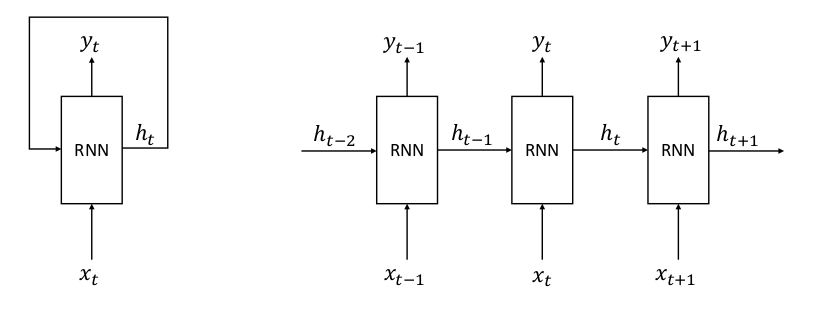

Above image shows a RNN and its unfolding in time. Generally, at time step $t$, the hidden state $h_t$ and output $y_t$  is updated as follows
\begin{align}
h_t &= \textrm{RNN}(h_{t-1}, x_t) \\
y_t &= \text{O}(h_t) = h_t
\end{align}

where $\textrm{RNN}$ and $O$ denotes the function that computes hidden state and output vector. In simplest case, output function can be identity function as shown in previous equation. The simplest RNN formulation is Elman Network  which used $\tanh$ as activation function
\begin{align}
h_t &=
\begin{cases}
	\tanh(h_{t_1}W^h + x_tW^x + b) & \quad    (t \geq 1) \\
	0 & \quad \text{ otherwise}
\end{cases} \\
\end{align}
where $W^h, W^x$ are weight matrices, $b$ is bias term.

#### Recurrent Neural Language Model
Similar to n-gram language model, the probability of a whole sentences are calculated by applying chained rules on probability of a word conditioned on previous words.
\begin{align}
P(\mathbf{w}) &= \prod_{i=1}^{n} P(w_{i}|\pmb{w}_{\le i-1}) = \prod_{i=1}^{n} \textrm{RNN}(h_{i-1}, w_i)
\end{align}

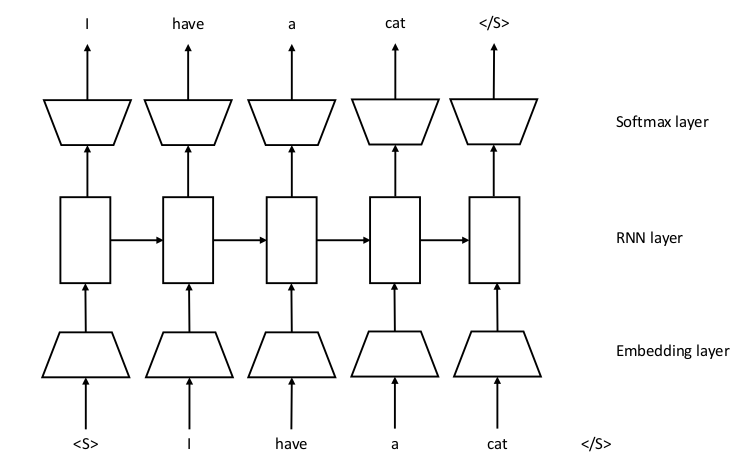

The training objective is to maximize the log likelihood of the correct words.

### Datasets & DataLoaders
Code for processing data samples can get messy and hard to maintain; we ideally want our dataset code to be decoupled from our model training code for better readability and modularity. PyTorch provides two data primitives: `torch.utils.data.DataLoader` and `torch.utils.data.Dataset` that allow you to use pre-loaded datasets as well as your own data. `Dataset` stores the samples and their corresponding labels, and `DataLoader` wraps an iterable around the `Dataset` to enable easy access to the samples.

#### Loading a dataset
We will load PennTreebank dataset with the following parameters:
- `root`: Directory where the datasets are saved. Default: .data
-  `split`: split or splits to be returned. Can be a string or tuple of strings. Default: (‘train’, ‘valid’, ‘test’)

In [33]:
from torchtext.datasets import PennTreebank
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torchtext import data

import torchtext
print(torchtext.__version__)

0.6.0


In [34]:
#!pip install torchdata
!pip install portalocker

###  Note*: You would likely encounter a "NoneType" Error after runing the next code block. Don't Worry. Just click "Runtime" on the menu bar and then click "restart session and run all" This should fix the problem.

In [38]:
# train_iter, valid_iter, test_iter = PennTreebank(
#     root=".data",
#     split=('train', 'valid', 'test'))

TEXT = data.Field(tokenize='basic_english', lower=True)
train_iter, valid_iter, test_iter = PennTreebank.splits(TEXT)

num = 0
for _ in train_iter:
  num +=1

print(f"Train size: {num}")


Train size: 1


#### Dataset preprocess
We will tokenize and construct the vocabulary from the training dataset

In [39]:
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torch.utils.data import dataset

In [42]:
# tokenizer = get_tokenizer('basic_english')
# vocab = build_vocab_from_iterator(map(tokenizer, train_iter), specials=['<unk>'])
# vocab.set_default_index(vocab['<unk>'])

tokenizer = get_tokenizer('basic_english')
TEXT.build_vocab(train_iter)
vocab = TEXT.vocab

In [44]:
print(f"Vocabulary size: {len(vocab)}")
# print(f"The first 10 words in the vocabulary: {vocab.get_itos()[:10]}")
print(f"The first 10 words in the vocabulary: {vocab.itos[:10]}")

Vocabulary size: 9924
The first 10 words in the vocabulary: ['<unk>', '<pad>', 'the', '<eos>', 'n', 'of', 'to', 'a', 'in', 'and']


In [46]:
#The vocabulary block converts a list of tokens into integers.
# vocab(['here', 'is', 'an', 'example'])
[vocab.stoi[word] for word in ['here', 'is', 'an', 'example']]


[351, 16, 35, 476]

In [48]:
# Out-of-vocabulary tokens will be converted to `<unk>` (the default index)
# vocab(['here', 'is', 'an', 'unknown', 'token', 'asdfghj'])
[vocab.stoi[word] for word in ['here', 'is', 'an', 'unknown', 'token', 'asdfghj']]


[351, 16, 35, 6657, 0, 0]

In [52]:
def data_process(raw_text_iter):
    data = [torch.tensor([vocab.stoi.get(token, vocab.stoi['<unk>']) for token in item.text], dtype=torch.long) for item in raw_text_iter]
    return torch.cat(tuple(filter(lambda t: t.numel() > 0, data)))

train_iter, valid_iter, test_iter = PennTreebank.splits(TEXT)
train_stream = data_process(train_iter)
valid_stream = data_process(valid_iter)
test_stream = data_process(test_iter)


In [53]:
train_stream

tensor([9894, 9895, 9896,  ...,   10,    0,    3])

In [54]:
max_seq_length=10
from typing import Tuple, List
def create_data_tuples(source: torch.Tensor):
    return [[source[i:i + max_seq_length], source[i+1:i+ max_seq_length + 1]]
            for i in range(len(source) - max_seq_length)]


#### Create a Custom Dataset
A custom Dataset class must implement three functions: __init__, __len__, and __getitem__.

In [55]:
from torch.utils.data import Dataset
class LMDataset(Dataset):
    def __init__(self, source):
        self.source = source
        self.data = create_data_tuples(source)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


In [56]:
train_dataset = LMDataset(train_stream)
valid_dataset = LMDataset(valid_stream)
test_dataset = LMDataset(test_stream)


In [57]:
train_dataset[0]

[tensor([9894, 9895, 9896, 9898, 9899, 9900, 9904, 9905, 9906, 9907]),
 tensor([9895, 9896, 9898, 9899, 9900, 9904, 9905, 9906, 9907, 9908])]

#### Preparing your data for training with DataLoaders
The `Dataset` retrieves our dataset’s features and labels one sample at a time. While training a model, we typically want to pass samples in “minibatches”, reshuffle the data at every epoch to reduce model overfitting, and use Python’s `multiprocessing` to speed up data retrieval.

`DataLoader` is an iterable that abstracts this complexity for us in an easy API.

In [58]:
from torch.utils.data import DataLoader

batch_size = 64
eval_batch_size = 32

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=eval_batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=eval_batch_size, shuffle=True)

#### Iterate through the DataLoader
We have loaded that dataset into the `DataLoader` and can iterate through the dataset as needed. Each iteration below returns a batch of source and target sequences (containing batch_size=20 tuples respectively). Because we specified shuffle=True, after we iterate over all batches the data is shuffled (for finer-grained control over the data loading order, take a look at [Samplers](https://pytorch.org/docs/stable/data.html#data-loading-order-and-sampler)).

In [59]:
src, tgt = next(iter(train_dataloader))
print(f"Source batch shape: {src.size()}")
print(f"Target batch shape: {tgt.size()}")

Source batch shape: torch.Size([64, 10])
Target batch shape: torch.Size([64, 10])


### Build the Neural Network

#### Get Device for Training
We want to be able to train our model on a hardware accelerator like the GPU, if it is available. Let’s check to see if torch.cuda is available, else we continue to use the CPU.

In [73]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


#### Define the Class
We define our neural network by subclassing `nn.Module`, and initialize the neural network layers in `__init__`. Every `nn.Module` subclass implements the operations on input data in the `forward` method.

In [74]:
import torch.nn as nn
class WordLevelRecurrentLanguageModel(nn.Module):
    def __init__(self, vocab_size, embedding_size, hidden_size):
        super(WordLevelRecurrentLanguageModel, self).__init__()
        self.hidden_size = hidden_size
        self.embedding_size = embedding_size

        self.embedding = nn.Embedding(vocab_size, embedding_size)
        self.rnn = nn.RNN(embedding_size, hidden_size, batch_first=True)

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden_states):
        embedded = self.embedding(x)
        out, hidden_states = self.rnn(embedded, hidden_states)

        # Reshaping the outputs to batch_size * seq_length x hidden_size
        out = out.contiguous().view(-1, self.hidden_size)
        out = self.fc(out)
        return out, hidden_states

    def init_hidden_states(self, batch_size):
        hidden_states = torch.zeros(1, batch_size, self.hidden_size)
        return hidden_states


We create an instance of `WordLevelRecurrentLanguageModel`, and move it to the device, and print its structure.

In [75]:
vocab_size = len(vocab)
embedding_size = 64
hidden_size = 64
model = WordLevelRecurrentLanguageModel(vocab_size, embedding_size, hidden_size).to(device)

Many layers inside a neural network are parameterized, i.e. have associated weights and biases that are optimized during training. Subclassing `nn.Module` automatically tracks all fields defined inside your model object, and makes all parameters accessible using your model’s `parameters()` or `named_parameters()` methods.

In this example, we iterate over each parameter, and print its size and a preview of its values.

In [76]:
print(f"Model structure: {model}\n\n")

for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")

Model structure: WordLevelRecurrentLanguageModel(
  (embedding): Embedding(9924, 64)
  (rnn): RNN(64, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=9924, bias=True)
)


Layer: embedding.weight | Size: torch.Size([9924, 64]) | Values : tensor([[ 1.2978e+00,  1.3317e+00, -2.5921e-01, -2.7965e+00,  1.2515e+00,
         -7.5024e-02, -3.6530e+00, -1.3502e+00,  5.7137e-01,  8.2866e-01,
          7.5263e-01, -2.2778e+00,  8.3641e-01,  1.7621e-01,  7.3178e-01,
          5.1424e-01, -1.1380e+00, -4.8143e-01, -4.0448e-01,  1.4612e+00,
         -2.9087e-01,  7.8547e-02,  5.4844e-01, -4.1405e-01,  3.7054e-01,
         -5.1180e-01, -4.7978e-02,  1.3546e-01,  1.1121e+00,  1.8403e+00,
         -4.4366e-01,  1.1376e+00,  2.0071e+00, -6.4213e-01, -2.0076e+00,
         -8.2098e-01,  3.9751e-01,  1.5414e-01, -2.4204e-01, -1.6979e+00,
          6.1318e-01,  1.5039e+00, -1.5967e+00, -6.8871e-01,  2.4886e+00,
          6.7142e-01,  2.5495e-01,  1.4146e-01, -1.0672e+00,  4.6318e-01,
     

To use the model, we pass it the input data. This executes the model’s `forward`, along with some background operations. Do not call `model.forward()` directly!

Calling the model on the input returns a vocab-size -dimensional tensor with raw predicted values for each token. We get the prediction probabilities by passing it through an instance of the `nn.Softmax` module.

In [86]:
x = train_dataset[0][0].unsqueeze(0).to(device)
hidden_states = model.init_hidden_states(1).to(device)
logits, states = model(x, hidden_states)
pred_probab = nn.Softmax(dim=1)(logits)
y_pred = pred_probab.argmax(1)
print(f"Predicted tokens: {y_pred}")

Predicted tokens: tensor([4, 0, 0, 0, 3, 2, 3, 3, 3, 3], device='cuda:0')


### Optimizing Model Parameters
Now that we have a model and data it’s time to train, validate and test our model by optimizing its parameters on our data. Training a model is an iterative process; in each iteration (called an `epoch`) the model makes a guess about the output, calculates the error in its guess (`loss`), collects the derivatives of the error with respect to its parameters, and optimizes these parameters using gradient descent.

Hyperparameters are adjustable parameters that let you control the model optimization process. Different hyperparameter values can impact model training and convergence rates (read more about hyperparameter tuning)

We define the following hyperparameters for training:

- Number of Epochs - the number times to iterate over the dataset
- Batch Size - the number of data samples propagated through the network before the parameters are updated
- Learning Rate - how much to update models parameters at each batch/epoch. Smaller values yield slow learning speed, while large values may result in unpredictable behavior during training.



In [87]:
learning_rate = 1e-3
batch_size = 64
epochs = 5

#### Optimization Loop

Once we set our hyperparameters, we can then train and optimize our model with an optimization loop. Each iteration of the optimization loop is called an epoch.

Each epoch consists of two main parts:

- The Train Loop - iterate over the training dataset and try to converge to optimal parameters.
- The Validation/Test Loop - iterate over the test dataset to check if model performance is improving.

Let’s briefly familiarize ourselves with some of the concepts used in the training loop


#### Loss Function
When presented with some training data, our untrained network is likely not to give the correct answer. Loss function measures the degree of dissimilarity of obtained result to the target value, and it is the loss function that we want to minimize during training. To calculate the loss we make a prediction using the inputs of our given data sample and compare it against the true data label value.

Common loss functions include `nn.MSELoss` (Mean Square Error) for regression tasks, and `nn.NLLLoss` (Negative Log Likelihood) for classification. `nn.CrossEntropyLoss` combines `nn.LogSoftmax` and `nn.NLLLoss`.

We pass our model’s output logits to `nn.CrossEntropyLoss`, which will normalize the logits and compute the prediction error.

In [92]:
# Initialize the loss function
loss_fn = nn.CrossEntropyLoss()

#### Optimizer
Optimization is the process of adjusting model parameters to reduce model error in each training step. **Optimization algorithms** define how this process is performed (in this example we use Stochastic Gradient Descent). All optimization logic is encapsulated in the `optimizer` object. Here, we use the SGD optimizer; additionally, there are many [different optimizers](https://pytorch.org/docs/stable/optim.html) available in PyTorch such as ADAM and RMSProp, that work better for different kinds of models and data.

We initialize the optimizer by registering the model’s parameters that need to be trained, and passing in the learning rate hyperparameter.

In [96]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)


Inside the training loop, optimization happens in three steps:

- Call `optimizer.zero_grad()` to reset the gradients of model parameters. Gradients by default add up; to prevent double-counting, we explicitly zero them at each iteration.
- Backpropagate the prediction loss with a call to `loss.backward()`. PyTorch deposits the gradients of the loss w.r.t. each parameter.
- Once we have our gradients, we call `optimizer.step()` to adjust the parameters by the gradients collected in the backward pass.



#### Full Implementation
We define `train_loop` that loops over our optimization code, and `test_loop` that evaluates the model’s performance against our test data.

In [101]:
history_loss = []
history_dev_loss = []
model.to(device)
def train_loop(dataloader, model, loss_fn, optimizer):
    model.train() 
    size = len(dataloader.dataset)
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        X = X.to(device)
        y = y.to(device)
        batch_size = X.size()[0]
        hidden_states = model.init_hidden_states(batch_size).to(device)
        logits, states = model(X, hidden_states)
        loss = loss_fn(logits, y.view(-1))

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 1000 == 0:
            loss, current = loss.item(), batch * len(X)
            history_loss.append(loss)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss = 0

    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device)
            batch_size = X.size()[0]
            hidden_states = model.init_hidden_states(batch_size).to(device)
            logits, states = model(X, hidden_states)
            test_loss += loss_fn(logits, y.view(-1)).item()

    test_loss /= size
    history_dev_loss.append(loss)
    print(f"Avg loss: {test_loss:>8f} \n")

We initialize the loss function and optimizer, and pass it to `train_loop` and `test_loop`. Feel free to increase the number of epochs to track the model’s improving performance.

In [119]:
##### loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 10
model.to(device)
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(valid_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 6.710642  [    0/966470]
loss: 6.622372  [64000/966470]
loss: 6.452174  [128000/966470]
loss: 6.622242  [192000/966470]
loss: 6.525696  [256000/966470]
loss: 6.511818  [320000/966470]
loss: 6.580695  [384000/966470]
loss: 6.372817  [448000/966470]
loss: 6.535558  [512000/966470]
loss: 6.581067  [576000/966470]
loss: 6.556258  [640000/966470]
loss: 6.677485  [704000/966470]
loss: 6.542899  [768000/966470]
loss: 6.584197  [832000/966470]
loss: 6.575608  [896000/966470]
loss: 6.690742  [960000/966470]
Avg loss: 0.203961 

Epoch 2
-------------------------------
loss: 6.516397  [    0/966470]
loss: 6.473147  [64000/966470]
loss: 6.501997  [128000/966470]
loss: 6.318175  [192000/966470]
loss: 6.626102  [256000/966470]
loss: 6.335927  [320000/966470]
loss: 6.512364  [384000/966470]
loss: 6.361333  [448000/966470]
loss: 6.291543  [512000/966470]
loss: 6.603747  [576000/966470]
loss: 6.490150  [640000/966470]
loss: 6.704188  [704000/966470]
loss: 6

### Save and Load the Model
In this section we will look at how to persist model state with saving, loading and running model predictions.

In [124]:
import torch
import torchvision.models as models

#### Saving and Loading Model Weights

PyTorch models store the learned parameters in an internal state dictionary, called state_dict. These can be persisted via the torch.save method:

In [128]:
torch.save(model.state_dict(), 'model.pt')
print(optimizer)
print(model)

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)
WordLevelRecurrentLanguageModel(
  (embedding): Embedding(9924, 64)
  (rnn): RNN(64, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=9924, bias=True)
)


To load model weights, you need to create an instance of the same model first, and then load the parameters using load_state_dict() method.

In [131]:
model.load_state_dict(torch.load('model.pt'))
model.eval()

WordLevelRecurrentLanguageModel(
  (embedding): Embedding(9924, 64)
  (rnn): RNN(64, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=9924, bias=True)
)

### Excercises

---

1. Use your trained RNN Language Model to predict next word of the following sentence: _The quick brown fox jumps over_

In [134]:
def predict_next_word(sentence, model, vocab, tokenizer):
    model.eval()
    tokens = tokenizer(sentence)
    indices = [vocab.stoi.get(t, vocab.stoi['<unk>']) for t in tokens]
    input_tensor = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)
    
    with torch.no_grad():
        hidden = model.init_hidden_states(1).to(device)
        output, _ = model(input_tensor, hidden)
    
    last_output = output[-1, :]
    
    # Skip special tokens
    special_tokens = {'<eos>', '<unk>', '<pad>'}
    sorted_indices = last_output.argsort(descending=True)
    for idx in sorted_indices:
        word = vocab.itos[idx.item()]
        if word not in special_tokens:
            return word

print(predict_next_word("the quick brown fox jumps over", model, vocab, tokenizer))


the


2. So far, we have limit the max sequence length to 10 (_max_seq_length_).Investigate the effect of different max sequence length to the RNN language model.

In [136]:
results = []

for seq_len in [5, 10, 20, 35]:
    # Recreate dataset with new sequence length
    max_seq_length = seq_len
    
    train_dataset = LMDataset(train_stream)
    test_dataset = LMDataset(test_stream)
    train_dl = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_dl = DataLoader(test_dataset, batch_size=32, shuffle=True)
    
    # Train a fresh model
    test_model = WordLevelRecurrentLanguageModel(len(vocab), 64, 64).to(device)
    test_optimizer = torch.optim.SGD(test_model.parameters(), lr=1.0)
    
    for _ in range(3):  # 3 epochs per sequence length
        train_loop(train_dl, test_model, loss_fn, test_optimizer)
    
    # Evaluate
    total_loss = 0
    test_model.eval()
    with torch.no_grad():
        for batch in test_dl:
            X, y = batch[0].to(device), batch[1].to(device)
            hidden = test_model.init_hidden_states(X.size(0)).to(device)
            output, _ = test_model(X, hidden)
            total_loss += loss_fn(output, y.view(-1)).item()
    
    avg_loss = total_loss / len(test_dl)
    perplexity = torch.exp(torch.tensor(avg_loss)).item()
    results.append((seq_len, avg_loss, perplexity))
    print(f"seq_len={seq_len:>3} | Loss: {avg_loss:.4f} | Perplexity: {perplexity:.2f}")

print("\nSummary:")
print(f"{'Seq Length':<12} {'Loss':<10} {'Perplexity'}")
for seq_len, loss, ppl in results:
    print(f"{seq_len:<12} {loss:<10.4f} {ppl:.2f}")


loss: 9.256544  [    0/966475]
loss: 6.033179  [64000/966475]
loss: 5.918299  [128000/966475]
loss: 5.784555  [192000/966475]
loss: 5.539987  [256000/966475]
loss: 5.468796  [320000/966475]
loss: 5.768600  [384000/966475]
loss: 5.812488  [448000/966475]
loss: 5.077089  [512000/966475]
loss: 5.070298  [576000/966475]
loss: 5.116372  [640000/966475]
loss: 5.151553  [704000/966475]
loss: 4.960140  [768000/966475]
loss: 5.518636  [832000/966475]
loss: 5.338051  [896000/966475]
loss: 5.479862  [960000/966475]
loss: 5.116338  [    0/966475]
loss: 5.286660  [64000/966475]
loss: 5.253310  [128000/966475]
loss: 5.091101  [192000/966475]
loss: 5.558146  [256000/966475]
loss: 5.524154  [320000/966475]
loss: 5.093366  [384000/966475]
loss: 5.053854  [448000/966475]
loss: 4.814616  [512000/966475]
loss: 5.034833  [576000/966475]
loss: 5.192152  [640000/966475]
loss: 4.999090  [704000/966475]
loss: 5.022457  [768000/966475]
loss: 5.135572  [832000/966475]
loss: 4.828557  [896000/966475]
loss: 5.2680

#### **Ouput**

| Seq Length | Loss   | Perplexity |
|------------|--------|------------|
| 5          | 5.1779 | 177.30     |
| 10         | 5.1835 | 178.31     |
| 20         | 5.0901 | 162.41     |
| 35         | 5.0832 | 161.29     |

#### **Observations**

- **Longer sequences = lower perplexity** — seq_len 35 performs best (161.29) while seq_len 5 is worst (177.30)
- The improvement is modest (~10% difference), likely because the model is small and only trained for 3 epochs
- **Why longer is better**: longer sequences give the RNN more context to learn dependencies between words — e.g. with seq_len=5, the model only sees 5 words at a time, limiting what patterns it can learn
- **Trade-off**: longer sequences require more memory and are slower to train, so in practice you balance performance vs. computational cost

#### **Why Lower Perplexity is Better**

**Lower perplexity = better** because perplexity measures how "surprised" or "confused" the model is when it sees the next word.

- **Low perplexity** (e.g. 161) — the model is more confident and assigns higher probabilities to the correct next word. It has learned the language patterns well.
- **High perplexity** (e.g. 177) — the model is more confused and spreads probability across many words, meaning it's less sure which word comes next.

**Intuitive analogy:**

Imagine guessing the next word in *"The quick brown fox jumps over the..."*

- A **good model** (low perplexity) would strongly predict *"lazy"* — it has learned this common phrase
- A **bad model** (high perplexity) would spread its guesses equally across all 9924 words in the vocabulary — essentially random guessing

**Mathematically**, perplexity is:

Perplexity = e^(loss)

So it is directly tied to loss — lower loss → lower perplexity → better model. A perplexity of 161 means the model is effectively choosing between ~161 equally likely words at each step, whereas a perfect model would have perplexity close to 1.